# Wav2Vec2 Fine-tuning for RAVDESS Negative SER



Cấu hình chính:
- Dataset: RAVDESS audio speech actors 01-24
- Classes: `angry`, `sad`, `fear`, `disgust`, `neutral`
- Split: `train_test_split(test_size=0.2, random_state=42, stratify=label_id)`
- Sampling rate: 16 kHz
- Best checkpoint: chọn theo `eval_macro_f1`
- Output: model HuggingFace/PyTorch, curves, confusion matrix, predictions CSV, summary CSV


In [ ]:
# Check GPU
import torch

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('No GPU. In Colab: Runtime > Change runtime type > GPU')

CUDA available: True
GPU: Tesla T4


In [ ]:
# Install libraries if needed
# Run this cell in Google Colab before importing if packages are missing.
# !pip install -q transformers accelerate librosa soundfile scikit-learn matplotlib pandas

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Global configuration
import os
from pathlib import Path

PROJECT_DIR = "/content/drive/MyDrive/UIT/KLTN"
RAVDESS_ROOT = f"{PROJECT_DIR}/data/RAVDESS/audio_speech_actors_01-24"

MODEL_NAME = "Wav2Vec2"
MODEL_CHECKPOINT = "facebook/wav2vec2-base"
OUTPUT_DIR = f"{PROJECT_DIR}/outputs/wav2vec2_m01_ravdess_v2"
CSV_DIR = f"{PROJECT_DIR}/outputs/csv"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

print('MODEL_NAME:', MODEL_NAME)
print('MODEL_CHECKPOINT:', MODEL_CHECKPOINT)
print('RAVDESS_ROOT:', RAVDESS_ROOT)
print('RAVDESS exists:', os.path.exists(RAVDESS_ROOT))
print('OUTPUT_DIR:', OUTPUT_DIR)

if os.path.exists(RAVDESS_ROOT):
    print('First folders/files:', os.listdir(RAVDESS_ROOT)[:10])
else:
    raise FileNotFoundError('RAVDESS_ROOT does not exist. Please check PROJECT_DIR or dataset path.')

MODEL_NAME: Wav2Vec2
MODEL_CHECKPOINT: facebook/wav2vec2-base
RAVDESS_ROOT: /content/drive/MyDrive/UIT/KLTN/data/RAVDESS/audio_speech_actors_01-24
RAVDESS exists: True
OUTPUT_DIR: /content/drive/MyDrive/UIT/KLTN/outputs/wav2vec2_m01_ravdess_v2
First folders/files: ['Actor_02', 'Actor_11', 'Actor_09', 'Actor_10', 'Actor_12', 'Actor_08', 'Actor_01', 'Actor_15', 'Actor_13', 'Actor_05']


In [ ]:
# Imports and reproducibility
import os
import random
import json
import inspect
import numpy as np
import pandas as pd
import torch
import librosa
import matplotlib.pyplot as plt

from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    TrainingArguments,
    Trainer,
    set_seed
)

SEED = 42

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Torch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
# Build RAVDESS metadata for 5 target classes
RAVDESS_EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fear',
    '07': 'disgust',
    '08': 'surprise'
}

TARGET_EMOTIONS = ['angry', 'sad', 'fear', 'disgust', 'neutral']

rows = []
for root, dirs, files in os.walk(RAVDESS_ROOT):
    for file in files:
        if not file.lower().endswith('.wav'):
            continue

        # Example filename: 03-01-05-01-02-01-12.wav
        parts = file.replace('.wav', '').split('-')
        if len(parts) != 7:
            print('Skipped invalid filename:', file)
            continue

        emotion_code = parts[2]
        actor_id = parts[6]
        emotion = RAVDESS_EMOTION_MAP.get(emotion_code)

        if emotion in TARGET_EMOTIONS:
            rows.append({
                'path': os.path.join(root, file),
                'label': emotion,
                'actor': actor_id,
                'filename': file
            })

df = pd.DataFrame(rows)
if df.empty:
    raise ValueError('No RAVDESS samples were found. Check RAVDESS_ROOT and filename format.')

df = df.sort_values(['actor', 'label', 'filename']).reset_index(drop=True)

raw_csv_path = f"{CSV_DIR}/ravdess_m01_5class_raw.csv"
df.to_csv(raw_csv_path, index=False)

print('CSV saved to:', raw_csv_path)
print('Number of samples:', len(df))
print('Label distribution:')
print(df['label'].value_counts())
display(df.head())

CSV saved to: /content/drive/MyDrive/UIT/KLTN/outputs/csv/ravdess_m01_5class_raw.csv
Number of samples: 864
Label distribution:
label
angry      192
disgust    192
fear       192
sad        192
neutral     96
Name: count, dtype: int64


,path,label,actor,filename
0,/content/drive/MyDrive/UIT/KLTN/data/RAVDESS/a...,angry,01,03-01-05-01-01-01-01.wav
1,/content/drive/MyDrive/UIT/KLTN/data/RAVDESS/a...,angry,01,03-01-05-01-01-02-01.wav
2,/content/drive/MyDrive/UIT/KLTN/data/RAVDESS/a...,angry,01,03-01-05-01-02-01-01.wav
3,/content/drive/MyDrive/UIT/KLTN/data/RAVDESS/a...,angry,01,03-01-05-01-02-02-01.wav
4,/content/drive/MyDrive/UIT/KLTN/data/RAVDESS/a...,angry,01,03-01-05-02-01-01-01.wav


In [ ]:
# Quick audio sanity check
sample_path = df.iloc[0]['path']
audio, sr = librosa.load(sample_path, sr=None)

print('Sample path:', sample_path)
print('Original sampling rate:', sr)
print('Audio shape:', audio.shape)
print('Duration seconds:', len(audio) / sr)
print('Label:', df.iloc[0]['label'])

Sample path: /content/drive/MyDrive/UIT/KLTN/data/RAVDESS/audio_speech_actors_01-24/Actor_01/03-01-05-01-01-01-01.wav
Original sampling rate: 48000
Audio shape: (185786,)
Duration seconds: 3.8705416666666665
Label: angry


In [ ]:
# Encode labels
# Keep alphabetical order for reproducibility and consistent confusion matrix axes.
label_list = sorted(df['label'].unique().tolist())
label2id = {label: idx for idx, label in enumerate(label_list)}
id2label = {idx: label for label, idx in label2id.items()}

df['label_id'] = df['label'].map(label2id)

print('Labels:', label_list)
print('label2id:', label2id)
print('id2label:', id2label)
display(df.head())

Labels: ['angry', 'disgust', 'fear', 'neutral', 'sad']
label2id: {'angry': 0, 'disgust': 1, 'fear': 2, 'neutral': 3, 'sad': 4}
id2label: {0: 'angry', 1: 'disgust', 2: 'fear', 3: 'neutral', 4: 'sad'}


,path,label,actor,filename,label_id
0,/content/drive/MyDrive/UIT/KLTN/data/RAVDESS/a...,angry,01,03-01-05-01-01-01-01.wav,0
1,/content/drive/MyDrive/UIT/KLTN/data/RAVDESS/a...,angry,01,03-01-05-01-01-02-01.wav,0
2,/content/drive/MyDrive/UIT/KLTN/data/RAVDESS/a...,angry,01,03-01-05-01-02-01-01.wav,0
3,/content/drive/MyDrive/UIT/KLTN/data/RAVDESS/a...,angry,01,03-01-05-01-02-02-01.wav,0
4,/content/drive/MyDrive/UIT/KLTN/data/RAVDESS/a...,angry,01,03-01-05-02-01-01-01.wav,0


In [ ]:
# Train/test split: same policy as the previous Wav2Vec2 experiment
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df['label_id']
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('Train:', len(train_df))
print('Test:', len(test_df))
print('Train distribution:')
print(train_df['label'].value_counts())
print('Test distribution:')
print(test_df['label'].value_counts())

train_csv = f"{CSV_DIR}/ravdess_m01_train.csv"
test_csv = f"{CSV_DIR}/ravdess_m01_test.csv"
train_df.to_csv(train_csv, index=False)
test_df.to_csv(test_csv, index=False)

print('Saved split files:')
print(train_csv)
print(test_csv)

Train: 691
Test: 173
Train distribution:
label
disgust    154
sad        154
fear       153
angry      153
neutral     77
Name: count, dtype: int64
Test distribution:
label
angry      39
fear       39
sad        38
disgust    38
neutral    19
Name: count, dtype: int64
Saved split files:
/content/drive/MyDrive/UIT/KLTN/outputs/csv/ravdess_m01_train.csv
/content/drive/MyDrive/UIT/KLTN/outputs/csv/ravdess_m01_test.csv


In [ ]:
# Load feature extractor
SAMPLING_RATE = 16000
feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_CHECKPOINT)

print(feature_extractor)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

Wav2Vec2FeatureExtractor {
  "do_normalize": true,
  "feature_extractor_type": "Wav2Vec2FeatureExtractor",
  "feature_size": 1,
  "padding_side": "right",
  "padding_value": 0.0,
  "return_attention_mask": false,
  "sampling_rate": 16000
}



In [ ]:
# Dataset: read raw waveform and label
class SpeechEmotionDataset(Dataset):
    def __init__(self, dataframe, sampling_rate=16000):
        self.dataframe = dataframe.reset_index(drop=True)
        self.sampling_rate = sampling_rate

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        speech_array, _ = librosa.load(row['path'], sr=self.sampling_rate, mono=True)

        return {
            'input_values': speech_array.astype(np.float32),
            'labels': int(row['label_id'])
        }

train_dataset = SpeechEmotionDataset(train_df, sampling_rate=SAMPLING_RATE)
test_dataset = SpeechEmotionDataset(test_df, sampling_rate=SAMPLING_RATE)

sample = train_dataset[0]
print('Input length:', len(sample['input_values']))
print('Label id:', sample['labels'])
print('Label name:', id2label[sample['labels']])

Input length: 60861
Label id: 1
Label name: disgust


In [ ]:
# Data collator: padding/truncation per batch
MAX_DURATION_SECONDS = 5.0
MAX_LENGTH = int(SAMPLING_RATE * MAX_DURATION_SECONDS)

class DataCollatorAudioClassification:
    def __init__(self, feature_extractor, max_length, sampling_rate=16000):
        self.feature_extractor = feature_extractor
        self.max_length = max_length
        self.sampling_rate = sampling_rate

    def __call__(self, features):
        audio_arrays = [feature['input_values'] for feature in features]
        labels = [feature['labels'] for feature in features]

        batch = self.feature_extractor(
            audio_arrays,
            sampling_rate=self.sampling_rate,
            max_length=self.max_length,
            truncation=True,
            padding=True,
            return_tensors='pt'
        )
        batch['labels'] = torch.tensor(labels, dtype=torch.long)
        return batch

data_collator = DataCollatorAudioClassification(
    feature_extractor=feature_extractor,
    max_length=MAX_LENGTH,
    sampling_rate=SAMPLING_RATE
)

print('Data collator initialized.')
print('Max duration:', MAX_DURATION_SECONDS, 'seconds')
print('Max length:', MAX_LENGTH, 'samples')

Data collator initialized.
Max duration: 5.0 seconds
Max length: 80000 samples


In [ ]:
# Load pretrained SSL model for audio classification
num_labels = len(label_list)

model = AutoModelForAudioClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=num_labels,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True
)

# Freeze low-level convolutional feature encoder.
# This is usually safer for small SER datasets and matches the summary field below.
FREEZE_FEATURE_ENCODER = True
if FREEZE_FEATURE_ENCODER and hasattr(model, 'freeze_feature_encoder'):
    model.freeze_feature_encoder()

print('Number of labels:', num_labels)
print('Labels:', label_list)
print('Feature encoder frozen:', FREEZE_FEATURE_ENCODER)
print('Model loaded successfully.')

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 
projector.bias               | MISSING    | 
projector.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Number of labels: 5
Labels: ['angry', 'disgust', 'fear', 'neutral', 'sad']
Feature encoder frozen: True
Model loaded successfully.


In [ ]:
# Metrics: Accuracy and Macro F1
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        'accuracy': accuracy_score(labels, predictions),
        'macro_f1': f1_score(labels, predictions, average='macro')
    }

In [ ]:
# TrainingArguments
# The helper below supports both old and new Transformers argument names:
# - older: evaluation_strategy
# - newer: eval_strategy

def make_training_args():
    kwargs = dict(
        output_dir=OUTPUT_DIR,
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='macro_f1',
        greater_is_better=True,
        learning_rate=3e-5,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=2,
        num_train_epochs=15,
        warmup_ratio=0.1,
        weight_decay=0.01,
        logging_dir=f'{OUTPUT_DIR}/logs',
        logging_steps=10,
        report_to='none',
        fp16=torch.cuda.is_available(),
        seed=SEED,
        save_total_limit=3
    )

    sig = inspect.signature(TrainingArguments.__init__)
    if 'eval_strategy' in sig.parameters:
        kwargs['eval_strategy'] = 'epoch'
    else:
        kwargs['evaluation_strategy'] = 'epoch'

    return TrainingArguments(**kwargs)

training_args = make_training_args()
print(training_args)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval

In [ ]:
# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print('Trainer initialized.')

Trainer initialized.


In [ ]:
# Train model
train_result = trainer.train()

print('Training completed.')
print(train_result)
print('Best checkpoint:', trainer.state.best_model_checkpoint)
print('Best metric:', trainer.state.best_metric)

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,3.022388,1.431618,0.364162,0.217099
2,2.171729,0.924363,0.687861,0.585615
3,1.364191,0.715559,0.820809,0.820970
4,0.995738,0.572342,0.843931,0.838552
5,0.291196,0.481673,0.867052,0.855719
6,0.287880,0.510239,0.895954,0.883423


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training completed.
TrainOutput(global_step=1305, training_loss=0.6280729058601847, metrics={'train_runtime': 1206.5187, 'train_samples_per_second': 8.591, 'train_steps_per_second': 1.082, 'total_flos': 3.874484720605644e+17, 'train_loss': 0.6280729058601847, 'epoch': 15.0})
Best checkpoint: /content/drive/MyDrive/UIT/KLTN/outputs/wav2vec2_m01_ravdess_v2/checkpoint-1044
Best metric: 0.9211661033030897


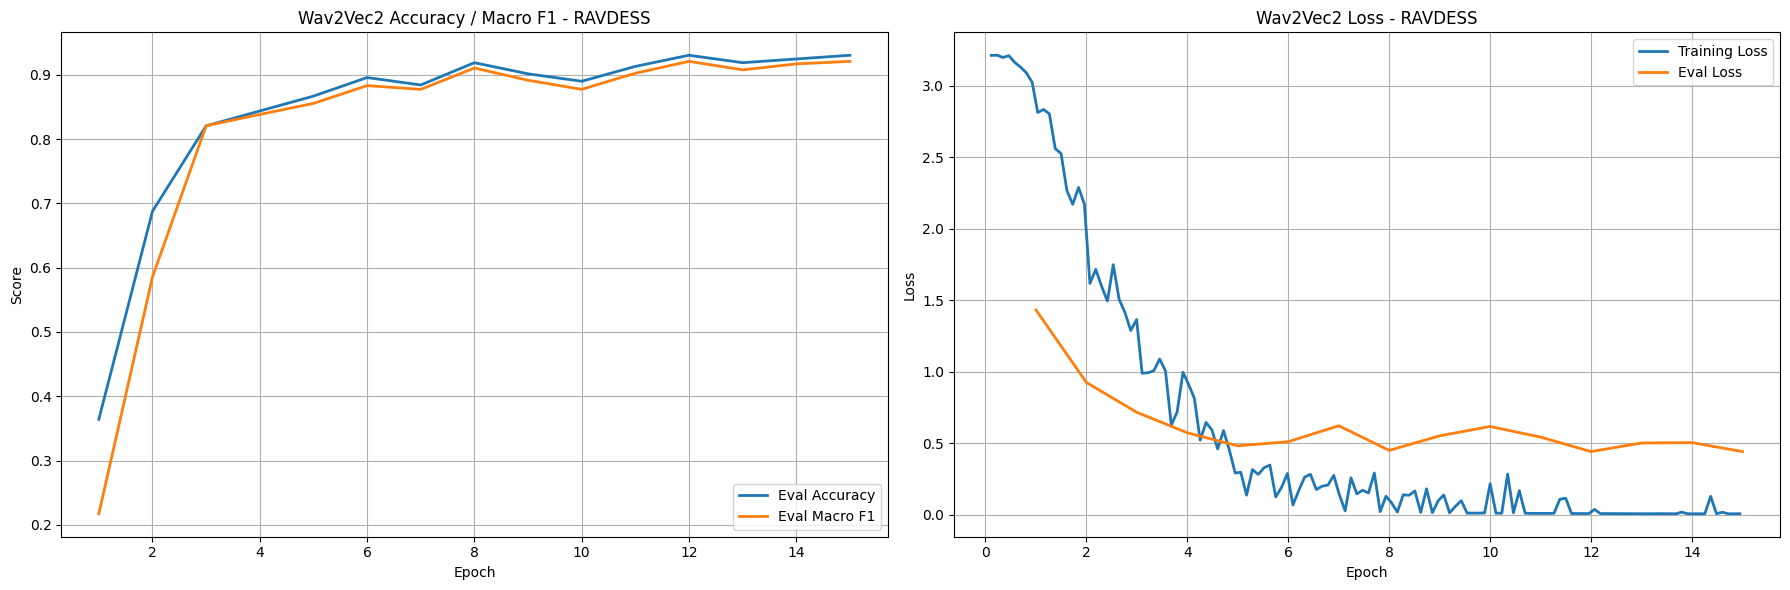

Saved curve figure to: /content/drive/MyDrive/UIT/KLTN/outputs/wav2vec2_m01_ravdess_v2/wav2vec2_training_curves.png


In [ ]:
# Plot training curves from Trainer logs
log_df = pd.DataFrame(trainer.state.log_history)

eval_df = log_df.dropna(subset=['eval_loss']).copy()
eval_cols = [col for col in ['epoch', 'eval_loss', 'eval_accuracy', 'eval_macro_f1'] if col in eval_df.columns]
eval_df = eval_df[eval_cols].drop_duplicates(subset=['epoch'], keep='last')

train_loss_df = log_df.dropna(subset=['loss']).copy()
train_loss_df = train_loss_df[['epoch', 'loss']].drop_duplicates(subset=['epoch'], keep='last')

plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
plt.plot(eval_df['epoch'], eval_df['eval_accuracy'], linewidth=2, label='Eval Accuracy')
plt.plot(eval_df['epoch'], eval_df['eval_macro_f1'], linewidth=2, label='Eval Macro F1')
plt.title(f'{MODEL_NAME} Accuracy / Macro F1 - RAVDESS')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.grid(True)
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(train_loss_df['epoch'], train_loss_df['loss'], linewidth=2, label='Training Loss')
plt.plot(eval_df['epoch'], eval_df['eval_loss'], linewidth=2, label='Eval Loss')
plt.title(f'{MODEL_NAME} Loss - RAVDESS')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(loc='upper right')

plt.tight_layout()
curve_path = f"{OUTPUT_DIR}/wav2vec2_training_curves.png"
plt.savefig(curve_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved curve figure to:', curve_path)

In [ ]:
# Save best model currently loaded by Trainer
# Because load_best_model_at_end=True, trainer.model is the best checkpoint by eval_macro_f1.
BEST_MODEL_DIR = f"{OUTPUT_DIR}/best_model"
trainer.save_model(BEST_MODEL_DIR)
feature_extractor.save_pretrained(BEST_MODEL_DIR)

metadata = {
    'model_name': MODEL_NAME,
    'model_checkpoint': MODEL_CHECKPOINT,
    'best_model_selection_metric': 'eval_macro_f1',
    'best_checkpoint': trainer.state.best_model_checkpoint,
    'best_metric': trainer.state.best_metric,
    'label2id': label2id,
    'id2label': id2label
}
with open(f"{BEST_MODEL_DIR}/training_metadata.json", 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print('Best model saved to:', BEST_MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved to: /content/drive/MyDrive/UIT/KLTN/outputs/wav2vec2_m01_ravdess_v2/best_model


In [ ]:
# Evaluate best model on the held-out test set
test_results = trainer.evaluate(test_dataset)

print('Test results:')
print(test_results)

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.006578,0.441295,15,0.930636,0.921166


Test results:
{'eval_loss': 0.44129475951194763, 'eval_accuracy': 0.930635838150289, 'eval_macro_f1': 0.9211661033030897}


In [ ]:
# Detailed predictions and classification report
pred_output = trainer.predict(test_dataset)

logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=-1)

test_accuracy = accuracy_score(y_true, y_pred)
test_macro_f1 = f1_score(y_true, y_pred, average='macro')

print('Test Accuracy:', test_accuracy)
print('Test Macro F1:', test_macro_f1)
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=label_list, digits=4))

Test Accuracy: 0.930635838150289
Test Macro F1: 0.9211661033030897
Classification Report:
              precision    recall  f1-score   support

       angry     0.9737    0.9487    0.9610        39
     disgust     1.0000    0.9211    0.9589        38
        fear     0.9737    0.9487    0.9610        39
     neutral     0.7200    0.9474    0.8182        19
         sad     0.9189    0.8947    0.9067        38

    accuracy                         0.9306       173
   macro avg     0.9173    0.9321    0.9212       173
weighted avg     0.9396    0.9306    0.9329       173



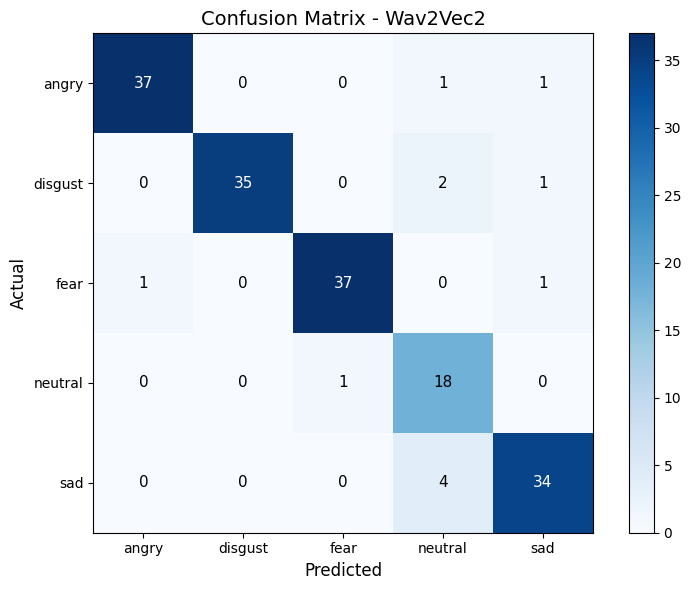

Saved confusion matrix image to: /content/drive/MyDrive/UIT/KLTN/outputs/wav2vec2_m01_ravdess_v2/confusion_matrix_wav2vec2_m01.png


In [ ]:
# Confusion matrix with the same blue visual format
cm = confusion_matrix(y_true, y_pred)
labels = label_list

plt.figure(figsize=(8, 6))
im = plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix - {MODEL_NAME}', fontsize=14)
plt.colorbar(im)

tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels, rotation=0)
plt.yticks(tick_marks, labels)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)

threshold = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], 'd'),
            ha='center', va='center',
            color='white' if cm[i, j] > threshold else 'black',
            fontsize=11
        )

plt.tight_layout()
cm_png_path = f"{OUTPUT_DIR}/confusion_matrix_wav2vec2_m01.png"
plt.savefig(cm_png_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved confusion matrix image to:', cm_png_path)

In [ ]:
# Save predictions for every test file
test_predictions_df = test_df.copy()
test_predictions_df['true_label'] = [id2label[int(i)] for i in y_true]
test_predictions_df['pred_label'] = [id2label[int(i)] for i in y_pred]
test_predictions_df['correct'] = test_predictions_df['true_label'] == test_predictions_df['pred_label']

pred_csv_path = f"{OUTPUT_DIR}/test_predictions_wav2vec2_m01.csv"
test_predictions_df.to_csv(pred_csv_path, index=False)

print('Test predictions saved to:', pred_csv_path)
display(test_predictions_df.head())

Test predictions saved to: /content/drive/MyDrive/UIT/KLTN/outputs/wav2vec2_m01_ravdess_v2/test_predictions_wav2vec2_m01.csv


,path,label,actor,filename,label_id,true_label,pred_label,correct
0,/content/drive/MyDrive/UIT/KLTN/data/RAVDESS/a...,angry,09,03-01-05-02-02-02-09.wav,0,angry,angry,True
1,/content/drive/MyDrive/UIT/KLTN/data/RAVDESS/a...,neutral,09,03-01-01-01-02-01-09.wav,3,neutral,neutral,True
2,/content/drive/MyDrive/UIT/KLTN/data/RAVDESS/a...,neutral,19,03-01-01-01-01-02-19.wav,3,neutral,neutral,True
3,/content/drive/MyDrive/UIT/KLTN/data/RAVDESS/a...,sad,19,03-01-04-02-02-02-19.wav,4,sad,sad,True
4,/content/drive/MyDrive/UIT/KLTN/data/RAVDESS/a...,sad,15,03-01-04-02-01-02-15.wav,4,sad,sad,True


In [ ]:
# Save experiment summary
summary = {
    'model_name': MODEL_NAME,
    'model_checkpoint': MODEL_CHECKPOINT,
    'dataset': 'RAVDESS m01 - 5 classes',
    'classes': ', '.join(label_list),
    'num_samples': len(df),
    'train_samples': len(train_df),
    'test_samples': len(test_df),
    'split': 'train_test_split(test_size=0.2, random_state=42, stratify=label_id)',
    'sampling_rate': SAMPLING_RATE,
    'max_duration_seconds': MAX_DURATION_SECONDS,
    'accuracy': test_accuracy,
    'macro_f1': test_macro_f1,
    'best_model_selection_metric': 'eval_macro_f1',
    'best_checkpoint': trainer.state.best_model_checkpoint,
    'best_metric': trainer.state.best_metric,
    'feature_encoder_frozen': FREEZE_FEATURE_ENCODER,
    'best_model_dir': BEST_MODEL_DIR,
    'curve_path': curve_path,
    'confusion_matrix_path': cm_png_path,
    'predictions_path': pred_csv_path
}

summary_df = pd.DataFrame([summary])
summary_csv_path = f"{OUTPUT_DIR}/summary_wav2vec2_m01.csv"
summary_df.to_csv(summary_csv_path, index=False)

display(summary_df)
print('Summary saved to:', summary_csv_path)

,model_name,model_checkpoint,dataset,classes,num_samples,train_samples,test_samples,split,sampling_rate,max_duration_seconds,accuracy,macro_f1,best_model_selection_metric,best_checkpoint,best_metric,feature_encoder_frozen,best_model_dir,curve_path,confusion_matrix_path,predictions_path
0,Wav2Vec2,facebook/wav2vec2-base,RAVDESS m01 - 5 classes,"angry, disgust, fear, neutral, sad",864,691,173,"train_test_split(test_size=0.2, random_state=4...",16000,5.0,0.930636,0.921166,eval_macro_f1,/content/drive/MyDrive/UIT/KLTN/outputs/wav2ve...,0.921166,True,/content/drive/MyDrive/UIT/KLTN/outputs/wav2ve...,/content/drive/MyDrive/UIT/KLTN/outputs/wav2ve...,/content/drive/MyDrive/UIT/KLTN/outputs/wav2ve...,/content/drive/MyDrive/UIT/KLTN/outputs/wav2ve...


Summary saved to: /content/drive/MyDrive/UIT/KLTN/outputs/wav2vec2_m01_ravdess_v2/summary_wav2vec2_m01.csv


In [ ]:
# Inference test with one audio file
from transformers import pipeline

classifier = pipeline(
    task='audio-classification',
    model=BEST_MODEL_DIR,
    feature_extractor=BEST_MODEL_DIR,
    device=0 if torch.cuda.is_available() else -1
)

sample_audio_path = test_df.iloc[0]['path']
true_label = test_df.iloc[0]['label']

result = classifier(sample_audio_path)

print('Audio:', sample_audio_path)
print('True label:', true_label)
print('Prediction:')
print(result)

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

Audio: /content/drive/MyDrive/UIT/KLTN/data/RAVDESS/audio_speech_actors_01-24/Actor_09/03-01-05-02-02-02-09.wav
True label: angry
Prediction:
[{'score': 0.997379720211029, 'label': 'angry'}, {'score': 0.0008355756872333586, 'label': 'fear'}, {'score': 0.000769049278460443, 'label': 'disgust'}, {'score': 0.0006703485269099474, 'label': 'neutral'}, {'score': 0.00034522483474574983, 'label': 'sad'}]
